# Customer Churn EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_churn_dataset-testing-master.csv')

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


In [5]:
df.shape

(64374, 12)

In [6]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [8]:
df.dtypes

CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

In [9]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


# Univariate Analysis (Numerical)

In [12]:
df["Total Spend"].mean()
df["Total Spend"].median()
df["Total Spend"].mode()
df["Total Spend"].std()
df["Total Spend"].var()
df["Total Spend"].skew()
df["Total Spend"].kurt()


np.float64(-1.2128996631514402)

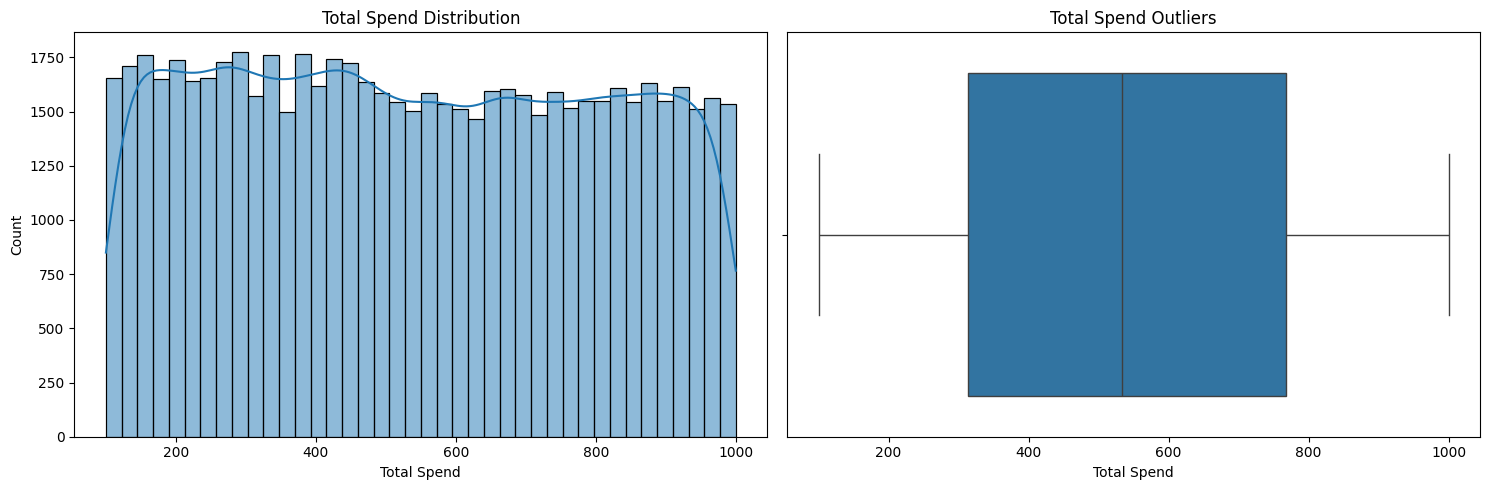

In [13]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df["Total Spend"], kde=True, ax=ax[0])
ax[0].set_title("Total Spend Distribution")

sns.boxplot(x=df["Total Spend"], ax=ax[1])
ax[1].set_title("Total Spend Outliers")

plt.tight_layout()
plt.show()


# Univariate Analysis (Categorical)

In [14]:
df["Subscription Type"].value_counts()
df["Subscription Type"].nunique()


3

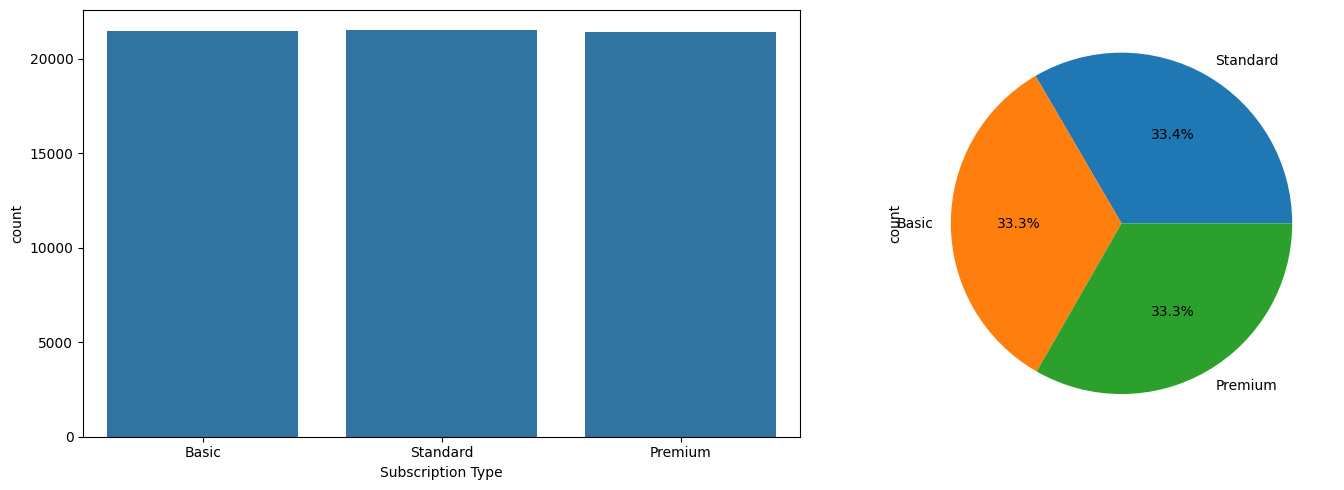

In [15]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.countplot(x=df["Subscription Type"], ax=ax[0])

df["Subscription Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax[1]
)

plt.tight_layout()
plt.show()


In [16]:
df["Age"].skew()
df["Age"].kurt()


np.float64(-1.2153207931818095)

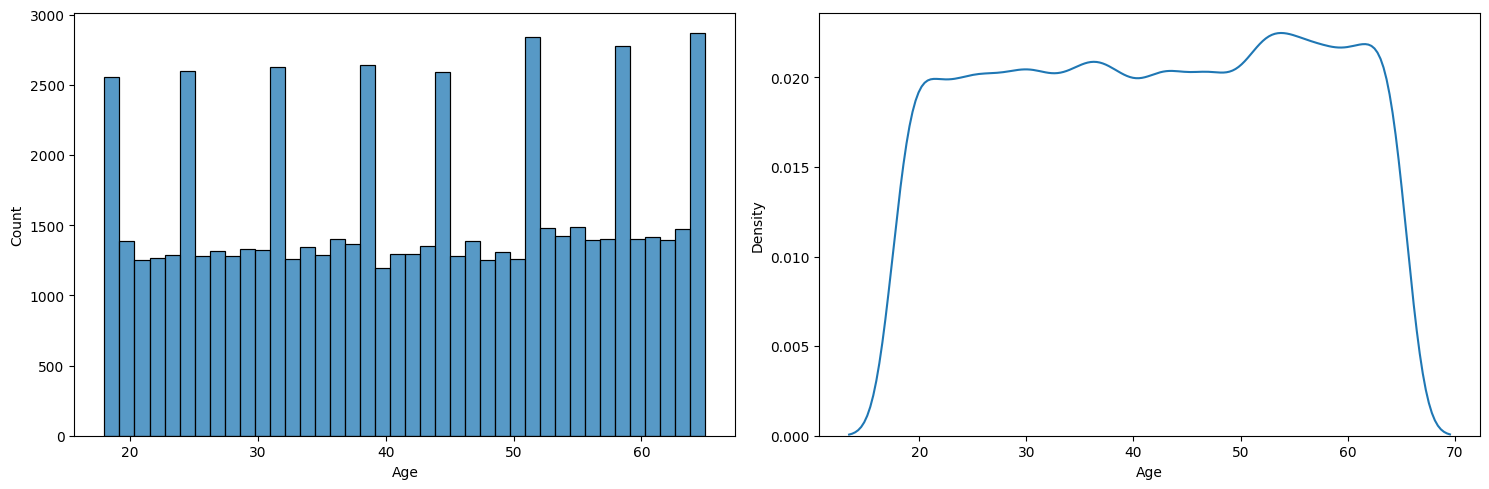

In [17]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df["Age"], ax=ax[0])
sns.kdeplot(df["Age"], ax=ax[1])

plt.tight_layout()
plt.show()


In [18]:
Q1 = df["Total Spend"].quantile(0.25)
Q3 = df["Total Spend"].quantile(0.75)
IQR = Q3 - Q1


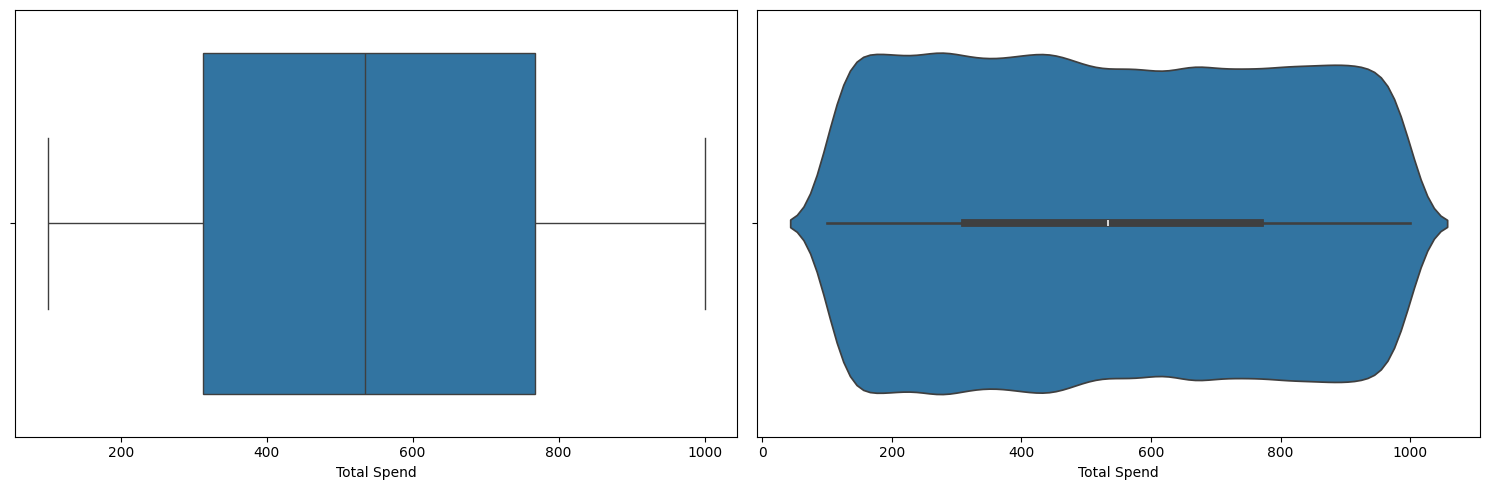

In [19]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.boxplot(x=df["Total Spend"], ax=ax[0])
sns.violinplot(x=df["Total Spend"], ax=ax[1])

plt.tight_layout()
plt.show()


# Bivariate Analysis

## Numerical vs Numerical

In [20]:
df[["Tenure","Total Spend"]].corr()

,Tenure,Total Spend
Tenure,1.000000,0.009474
Total Spend,0.009474,1.000000


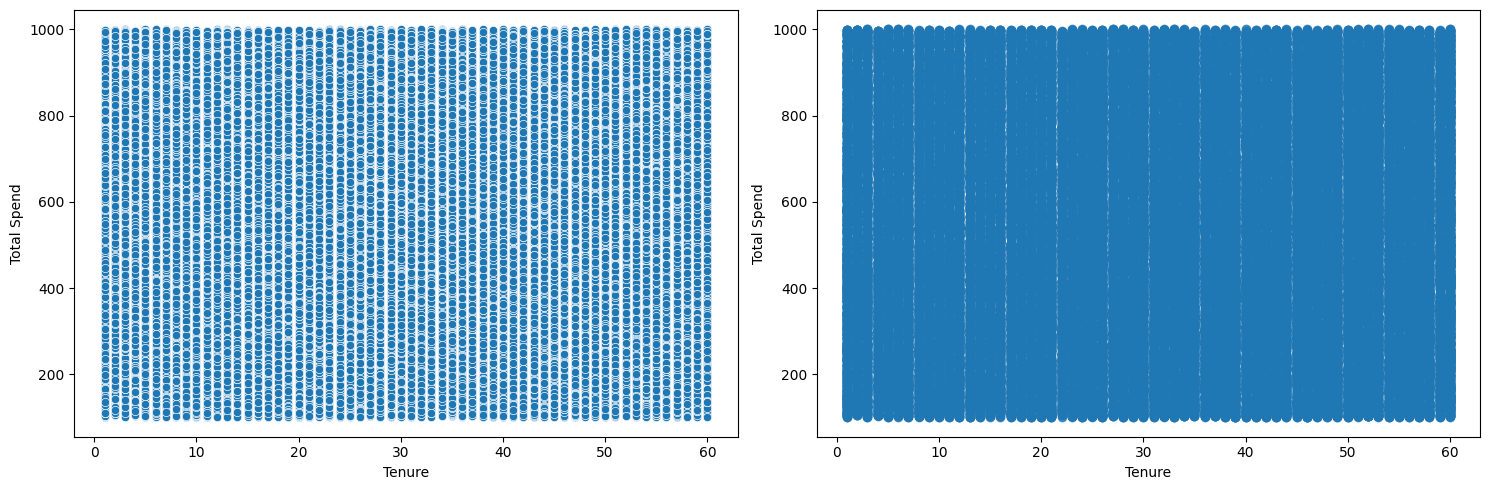

In [21]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.scatterplot(x=df["Tenure"], y=df["Total Spend"], ax=ax[0])

sns.regplot(x=df["Tenure"], y=df["Total Spend"], ax=ax[1])

plt.tight_layout()
plt.show()


## Numerical vs Categorical

In [22]:
df.groupby("Subscription Type")["Total Spend"].mean()

Subscription Type
Basic       540.908536
Premium     543.581579
Standard    538.589387
Name: Total Spend, dtype: float64

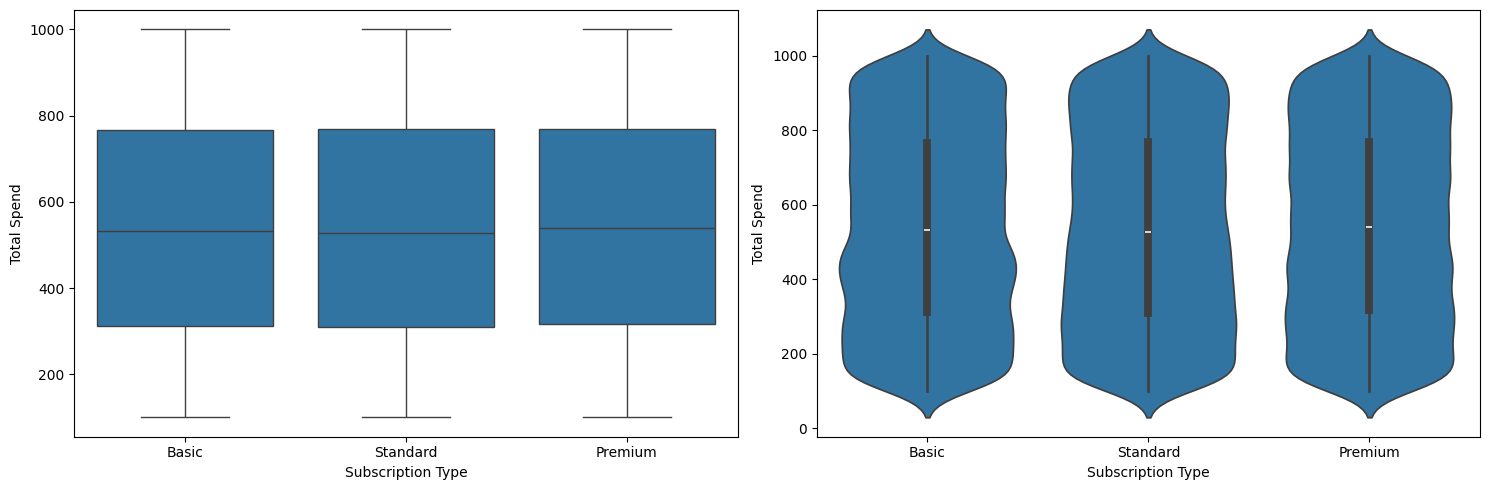

In [23]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.boxplot(
    x="Subscription Type",
    y="Total Spend",
    data=df,
    ax=ax[0]
)

sns.violinplot(
    x="Subscription Type",
    y="Total Spend",
    data=df,
    ax=ax[1]
)

plt.tight_layout()
plt.show()


# Correlation Analysis

In [26]:
corr = df.corr(numeric_only=True)

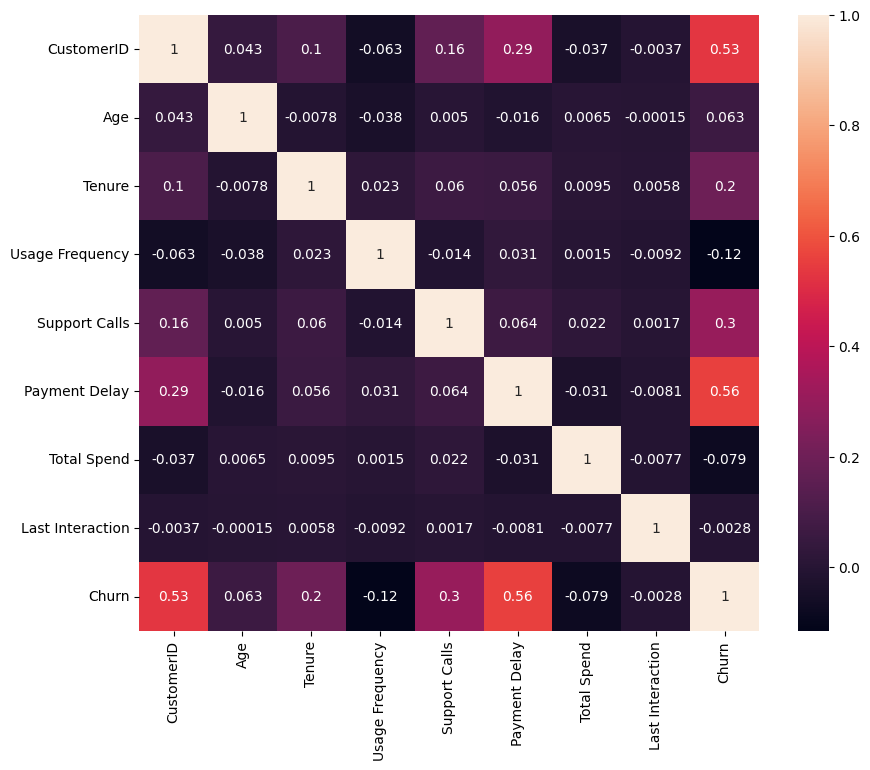

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True)

plt.show()


In [28]:
df["Churn"].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

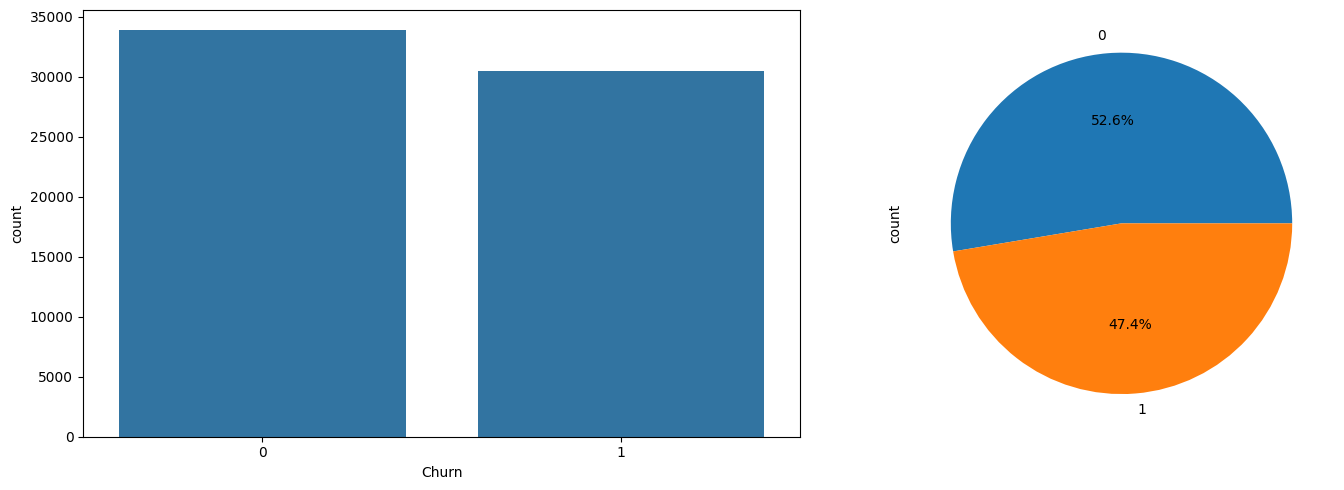

In [29]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.countplot(x=df["Churn"], ax=ax[0])

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax[1]
)

plt.tight_layout()
plt.show()


In [30]:
df.groupby("Churn")["Total Spend"].mean()

Churn
0    560.541956
1    519.336143
Name: Total Spend, dtype: float64

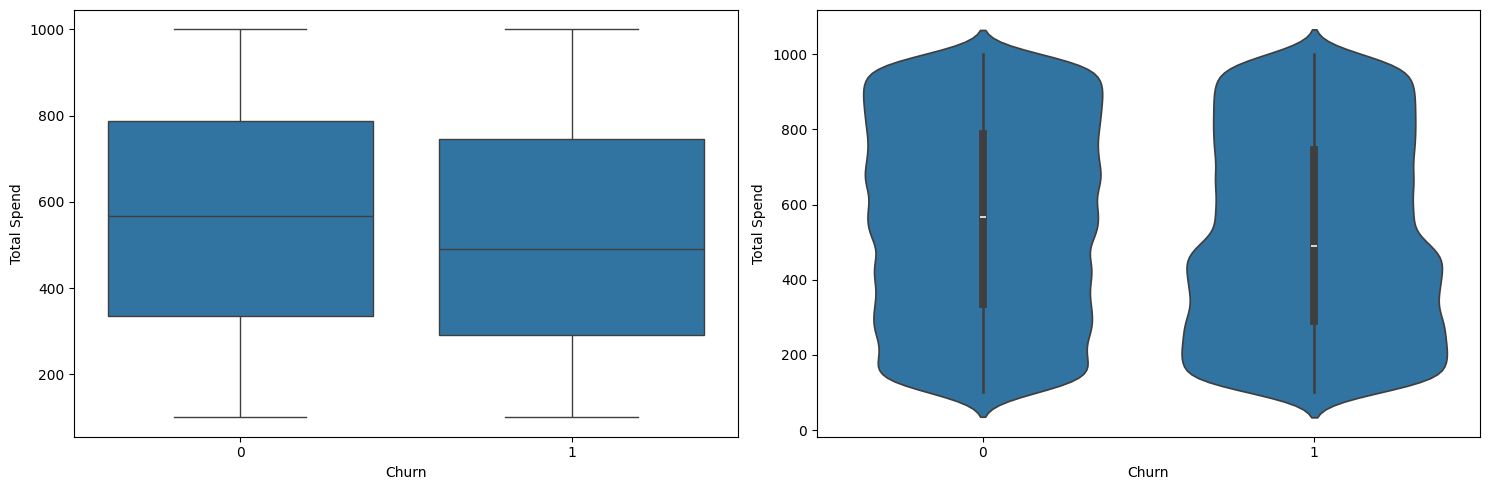

In [31]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

sns.boxplot(
    x="Churn",
    y="Total Spend",
    data=df,
    ax=ax[0]
)

sns.violinplot(
    x="Churn",
    y="Total Spend",
    data=df,
    ax=ax[1]
)

plt.tight_layout()
plt.show()


# Multivariate Analysis

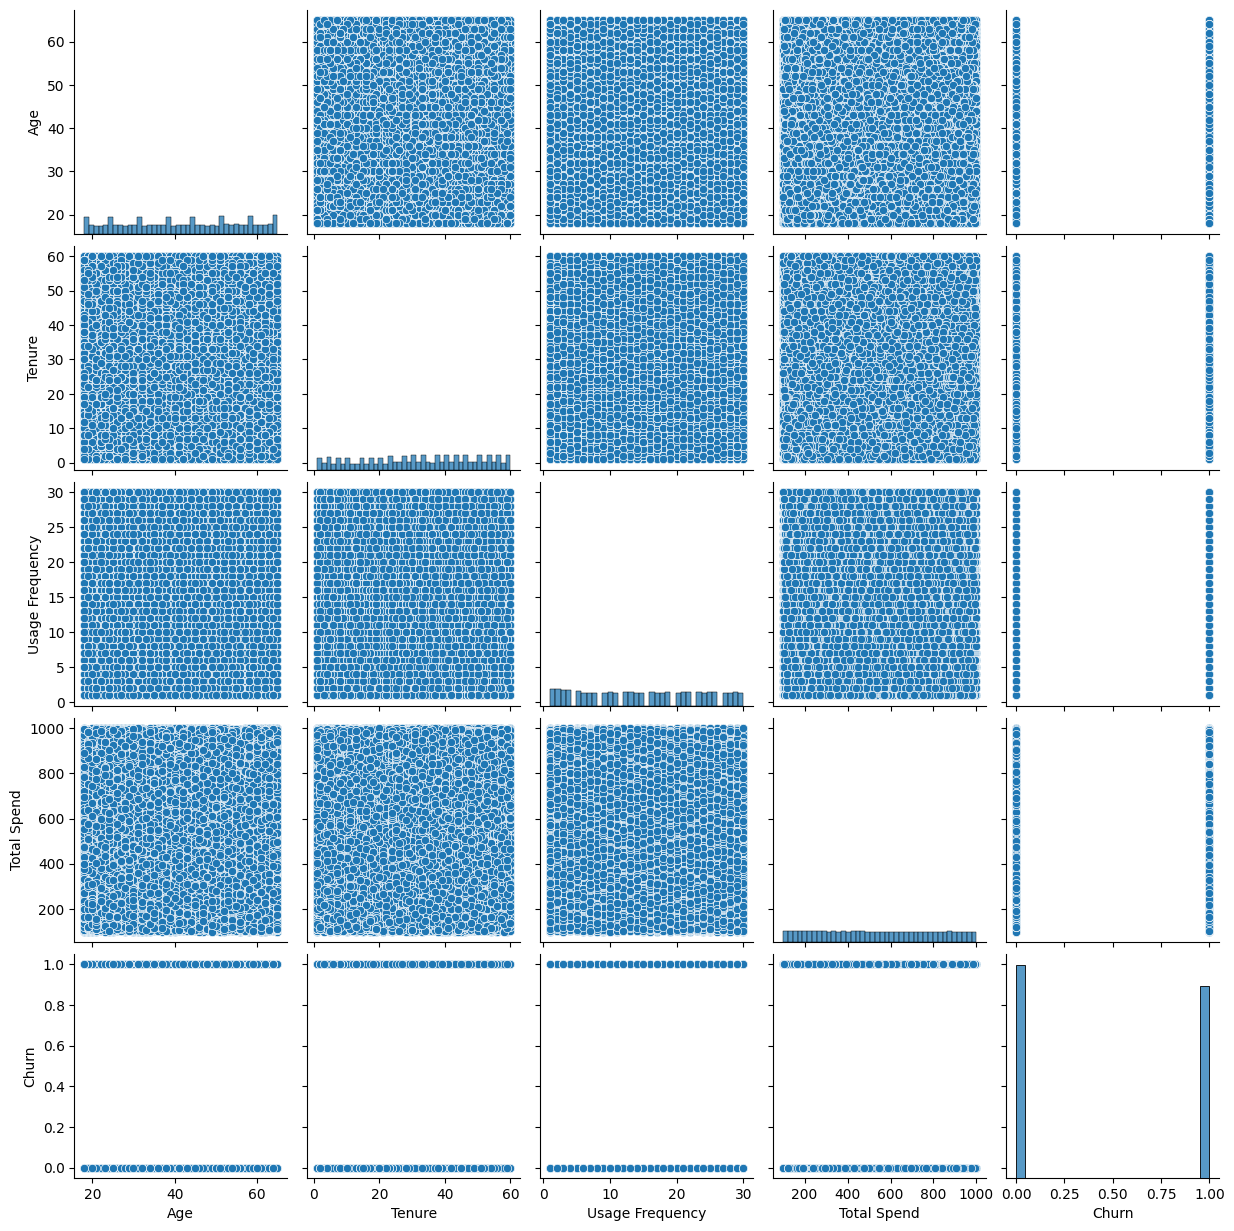

In [32]:
sns.pairplot(
    df[[
        "Age",
        "Tenure",
        "Usage Frequency",
        "Total Spend",
        "Churn"
    ]]
)
plt.show()


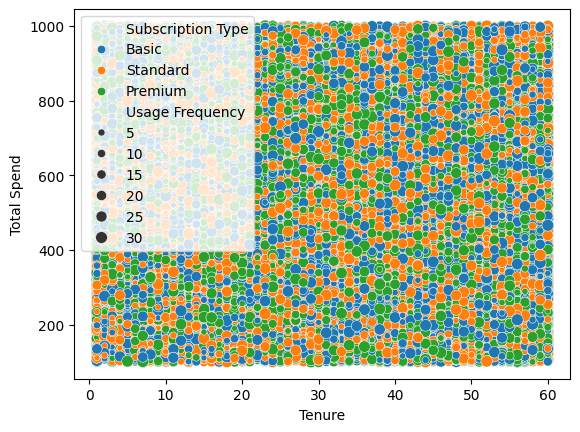

In [33]:
sns.scatterplot(
    x=df["Tenure"],
    y=df["Total Spend"],
    hue=df["Subscription Type"],
    size=df["Usage Frequency"]
)

plt.show()


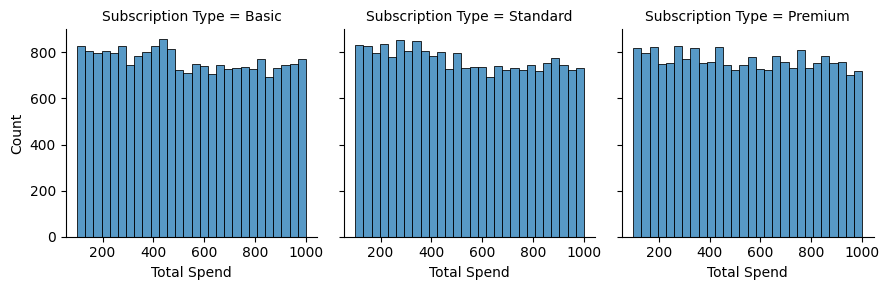

In [34]:
g = sns.FacetGrid(
    df,
    col="Subscription Type"
)

g.map(
    sns.histplot,
    "Total Spend"
)

plt.show()
